In [1]:
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2026-06-30 08:07:31.803093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782806852.035335      40 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782806852.105511      40 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [3]:
train_path='/kaggle/input/brain-tumor-mri-dataset/Training'
test_path='/kaggle/input/brain-tumor-mri-dataset/Testing'

In [4]:
train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 rotation_range=0.2,
                                 zoom_range=0.2,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 horizontal_flip=True)

In [5]:
train_data=train_datagen.flow_from_directory(
    shuffle=True,
    directory=train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical')

Found 5600 images belonging to 4 classes.


In [6]:
train_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [7]:
test_datagen=train_datagen=ImageDataGenerator(rescale=1./255)

In [8]:
test_data=train_datagen.flow_from_directory(shuffle=False,
    directory=test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical')

Found 1600 images belonging to 4 classes.


In [9]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20,20))
    axes = axes.flatten()
    for img,ax in zip( images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

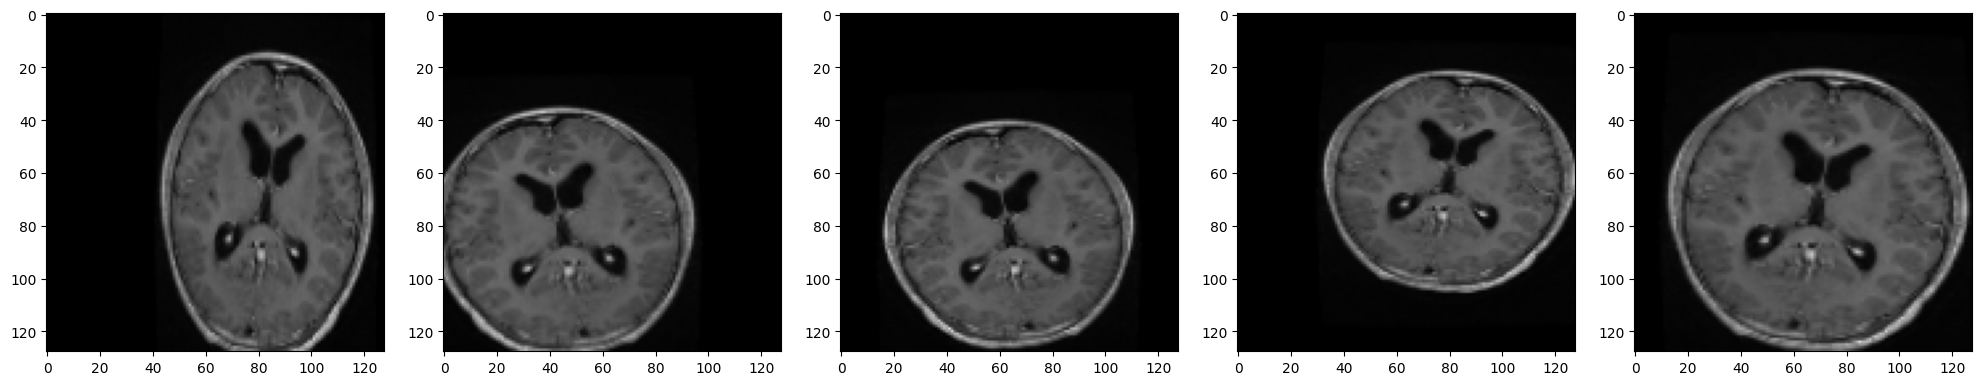

In [10]:
images=[train_data[0][0][0] for i in range(5)]
plotImages(images)

In [13]:
model=keras.models.Sequential()
model.add(keras.layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(filters=256,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(units=128,activation='relu'))
model.add(keras.layers.Dropout(0.1))
model.add(keras.layers.Dense(units=256,activation='relu'))
model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Dense(units=4,activation='softmax'))

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,860 (2.13 MB)

 Trainable params: 557,860 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [16]:
history=model.fit(train_data,epochs=100,validation_data=test_data)

Epoch 1/100


I0000 00:00:1782807018.714880     121 service.cc:148] XLA service 0x7fb4680049e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782807018.715978     121 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782807018.716011     121 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782807019.197444     121 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/175 ━━━━━━━━━━━━━━━━━━━━ 25:08 9s/step - accuracy: 0.2188 - loss: 1.3852

I0000 00:00:1782807023.528983     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 67s 336ms/step - accuracy: 0.3865 - loss: 1.2368 - val_accuracy: 0.4363 - val_loss: 1.6300
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 189ms/step - accuracy: 0.6156 - loss: 0.9210 - val_accuracy: 0.4719 - val_loss: 1.7521
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 190ms/step - accuracy: 0.6885 - loss: 0.7981 - val_accuracy: 0.5244 - val_loss: 1.5444
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.7183 - loss: 0.6989 - val_accuracy: 0.6556 - val_loss: 1.0699
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/step - accuracy: 0.7779 - loss: 0.5907 - val_accuracy: 0.5612 - val_loss: 1.6755
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/step - accuracy: 0.8081 - loss: 0.5193 - val_accuracy: 0.6737 - val_loss: 1.2533
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.8307 - loss: 0.4590 - val_accuracy: 0.6875 - val_loss: 1.2494
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 189ms/step - accuracy: 0.8361 - loss: 0.435

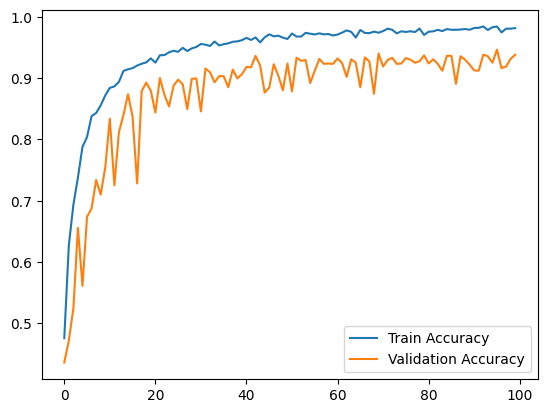

In [17]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

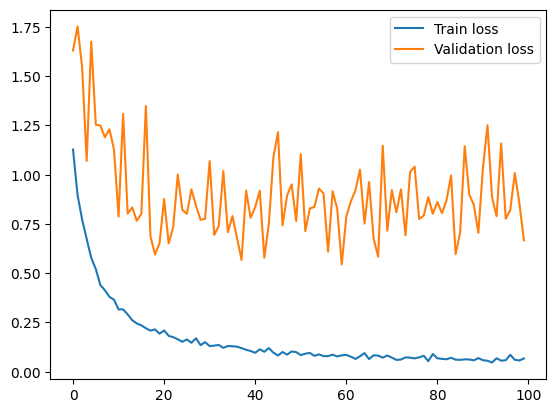

In [18]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

In [19]:
y_prob=model.predict(test_data)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step


In [20]:
y_true=test_data.classes

In [21]:
y_pred=np.argmax(y_prob,axis=1)

In [22]:
from sklearn.metrics import confusion_matrix

In [23]:
cm=confusion_matrix(y_true,y_pred)

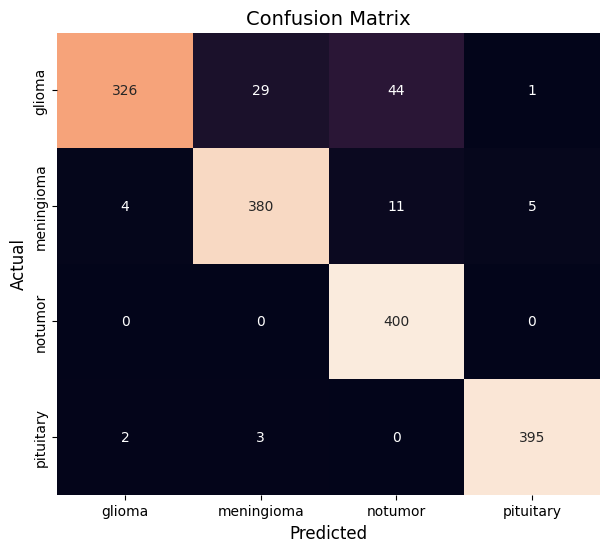

In [24]:
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [26]:
n_classes = 4
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

In [27]:
y_true = y_true
y_score = y_prob

In [28]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

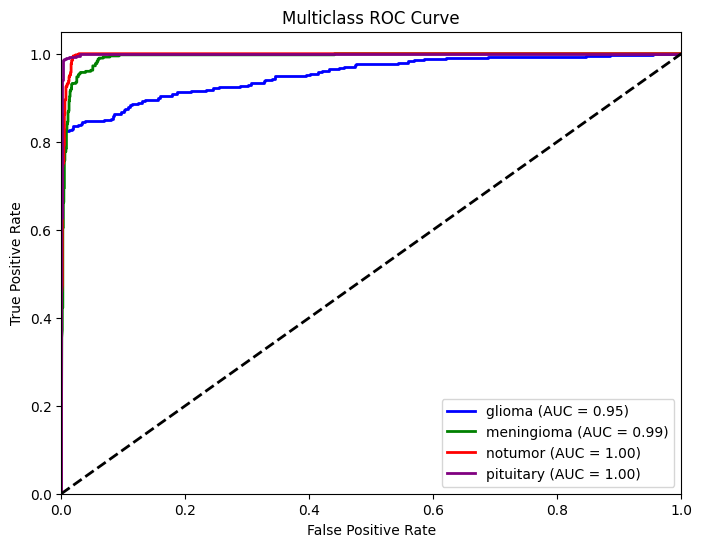

In [29]:
plt.figure(figsize=(8,6))

colors = ['blue', 'green', 'red', 'purple']
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [30]:
from sklearn.metrics import f1_score,precision_score,recall_score

In [31]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

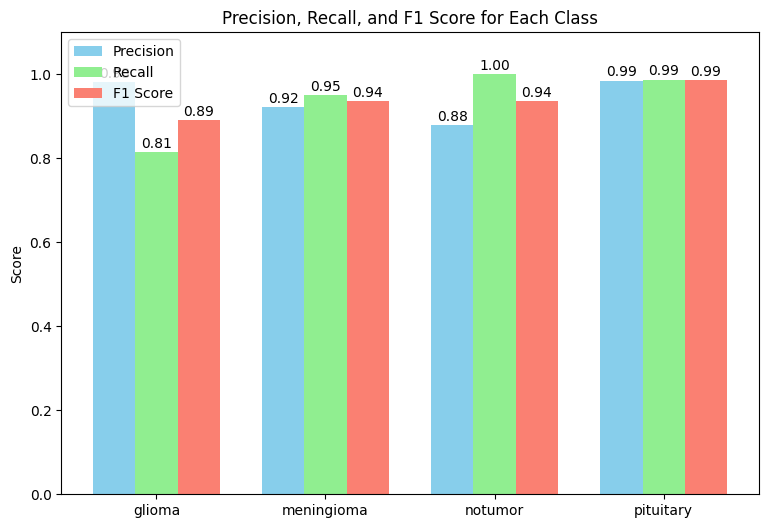

In [32]:
x = np.arange(len(class_names))  # label locations
width = 0.25  # width of each bar

plt.figure(figsize=(9,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1 Score', color='salmon')

# Add values on top of bars
for i in range(len(class_names)):
    plt.text(x[i] - width, precision[i]+0.01, f'{precision[i]:.2f}', ha='center', fontsize=10)
    plt.text(x[i], recall[i]+0.01, f'{recall[i]:.2f}', ha='center', fontsize=10)
    plt.text(x[i] + width, f1[i]+0.01, f'{f1[i]:.2f}', ha='center', fontsize=10)

plt.xticks(x, class_names)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score for Each Class')
plt.legend()
plt.show()


In [33]:
from sklearn.metrics import classification_report

In [34]:
print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))

              precision    recall  f1-score   support

      glioma       0.98      0.81      0.89       400
  meningioma       0.92      0.95      0.94       400
     notumor       0.88      1.00      0.94       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



In [35]:
# Save the best model
model.save("brain_tumor_model.keras")

In [36]:
import os

print(os.listdir())

['brain_tumor_model.keras', '.virtual_documents']


In [37]:
from IPython.display import FileLink

FileLink("brain_tumor_model.keras")

/kaggle/working/brain_tumor_model.keras